In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit
from Analysis import WaveformAnalysis, WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit


In [3]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)

In [4]:
import sklearn
from sklearn.decomposition import PCA

In [5]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [6]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

In [7]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_env_ene(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        # q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        # q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)):
                t = t
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

Fogi timing

In [8]:
header = "D:/K_sunada/result/CDY170/"

In [9]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_timing(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_delay = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        d = dd['delay']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_wo_fogi_rx']['values'][k:k+num_of_fogi_freq]
        # q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_delay.append(d)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        # q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_delay[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)):
                t = t
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
                
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_delay, time, waveform, waveform_zero_fogi, energys, rates, [],y_absorbed_envs, y_base_envs

photon freq = 9.35

photon 0

In [10]:
ph0_fo0 = "/2024-11-15/2024-11-15T001355_10b29d98-j1_JPA_comm_timing"
ph0_fo1 = "/2024-11-15/2024-11-15T013622_952f581a-j1_JPA_comm_timing"
ph0_fo2 = "/2024-11-15/2024-11-15T025858_1f22fa39-j1_JPA_comm_timing"
ph0_fo3 = "/2024-11-15/2024-11-15T042148_b18c4074-j1_JPA_comm_timing"

In [11]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo0
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d00 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time00 = d00[0][ph_amp]
ph0fo0 = d00[5][ph_amp]

In [12]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo1
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d01 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time01 = d01[0][ph_amp]
ph0fo1 = d01[5][ph_amp]

In [13]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo2
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d02 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time02 = d02[0][ph_amp]
ph0fo2 = d02[5][ph_amp]

In [14]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo3
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d03 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time03 = d03[0][ph_amp]
ph0fo3 = d03[5][ph_amp]

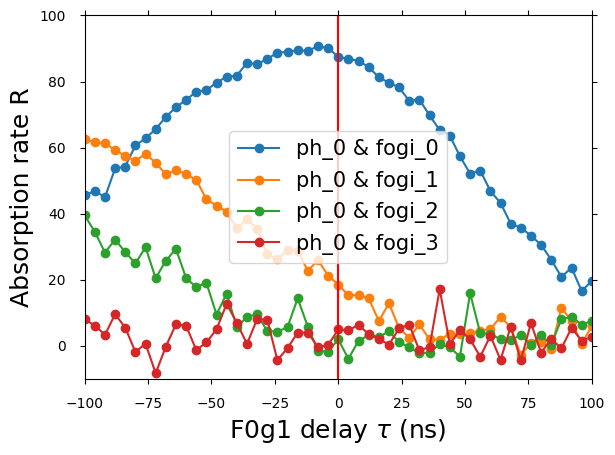

In [15]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time00, ph0fo0, "o-", label= "ph_0 & fogi_0")
plt.plot(time01, ph0fo1, "o-", label= "ph_0 & fogi_1")
plt.plot(time02, ph0fo2, "o-", label= "ph_0 & fogi_2")
plt.plot(time03, ph0fo3, "o-", label= "ph_0 & fogi_3")
plt.vlines(0, -10, 100, color="r")
plt.legend()
plt.show()

79.63
12.8


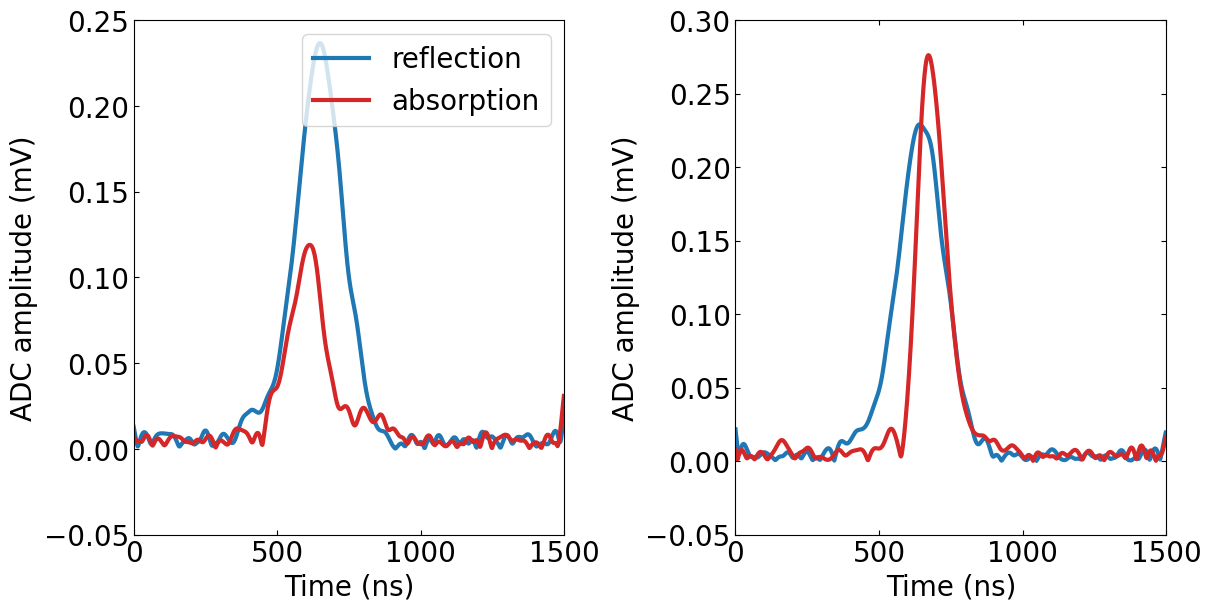

In [114]:
## waveform
ph_amp = 0
fogi_freq = 30

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
# ax[0].plot(d00[1][ph_amp][fogi_freq],  (d00[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[0].plot(d00[1][ph_amp][fogi_freq],  (d00[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue', label=r"reflection")
# ax[0].plot(d00[1][ph_amp][fogi_freq],  (d00[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[0].plot(d00[1][ph_amp][fogi_freq],  (d00[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red', label=r"absorption")
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.05, 0.25)
ax[0].set_xlim(0, 1500)
ax[0].legend()

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
# ax[1].plot(d01[1][ph_amp][fogi_freq],  (d01[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[1].plot(d01[1][ph_amp][fogi_freq],  (d01[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[1].plot(d01[1][ph_amp][fogi_freq],  (d01[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[1].plot(d01[1][ph_amp][fogi_freq],  (d01[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_ylim(-0.05, 0.3)
ax[1].set_xlim(0, 1500)

print(np.round(d00[5][ph_amp][fogi_freq], 2))
print(np.round(d01[5][ph_amp][fogi_freq], 2))
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_14852\1081746543.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


4.33
0.31


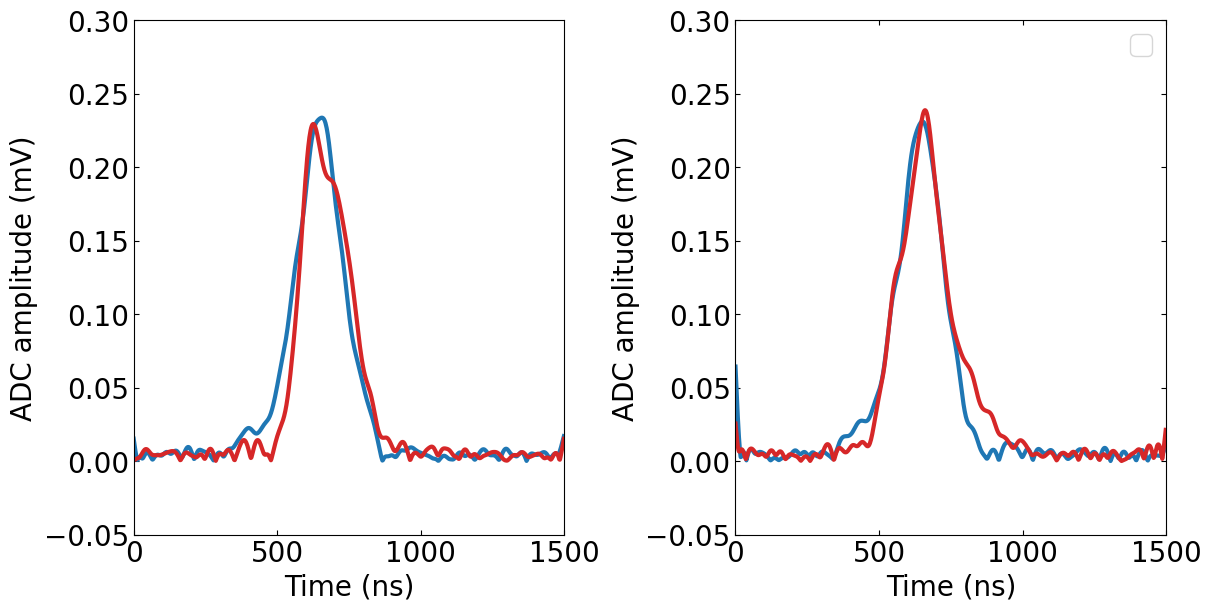

In [115]:
## waveform
ph_amp = 0
fogi_freq = 30

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
# ax[0].plot(d02[1][ph_amp][fogi_freq],  (d02[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[0].plot(d02[1][ph_amp][fogi_freq],  (d02[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[0].plot(d02[1][ph_amp][fogi_freq],  (d02[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[0].plot(d02[1][ph_amp][fogi_freq],  (d02[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.05, 0.3)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
# ax[1].plot(d03[1][ph_amp][fogi_freq],  (d03[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[1].plot(d03[1][ph_amp][fogi_freq],  (d03[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[1].plot(d03[1][ph_amp][fogi_freq],  (d03[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[1].plot(d03[1][ph_amp][fogi_freq],  (d03[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_ylim(-0.05, 0.3)
ax[1].set_xlim(0, 1500)
plt.legend()
print(np.round(d02[5][ph_amp][fogi_freq], 2))
print(np.round(d03[5][ph_amp][fogi_freq], 2))
plt.show()

phototn 1

In [18]:
ph1_fo0 = "/2024-11-15/2024-11-15T054442_463307ed-j1_JPA_comm_timing"
ph1_fo1 = "/2024-11-15/2024-11-15T070751_e41fe1d5-j1_JPA_comm_timing"
ph1_fo2 = "/2024-11-15/2024-11-15T083055_7eb1ba60-j1_JPA_comm_timing"
ph1_fo3 = "/2024-11-15/2024-11-15T095427_2a3f8bc8-j1_JPA_comm_timing"

In [19]:
## absorption rate
ph_amp = 0
###############################################
data = ph1_fo0
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d10 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time10 = d10[0][ph_amp]
ph1fo0 = d10[5][ph_amp]

In [20]:
## absorption rate
ph_amp = 0
###############################################
data = ph1_fo1
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d11 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time11 = d11[0][ph_amp]
ph1fo1 = d11[5][ph_amp]

In [21]:
## absorption rate
ph_amp = 0
###############################################
data = ph1_fo2
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d12 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time12 = d12[0][ph_amp]
ph1fo2 = d12[5][ph_amp]

In [22]:
## absorption rate
ph_amp = 0
###############################################
data = ph1_fo3
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d13 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time13 = d13[0][ph_amp]
ph1fo3 = d13[5][ph_amp]

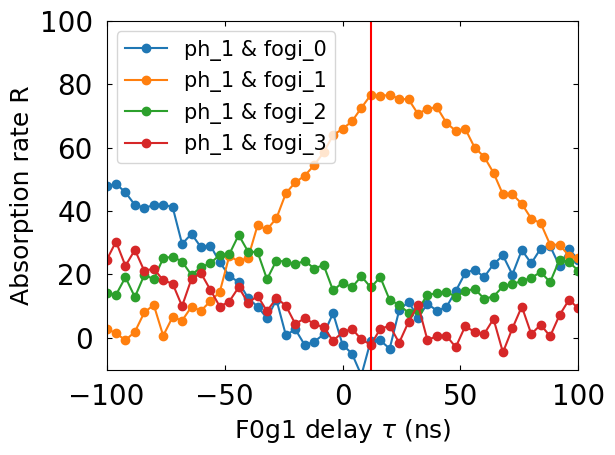

In [23]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time10, ph1fo0, "o-", label= "ph_1 & fogi_0")
plt.plot(time11, ph1fo1, "o-", label= "ph_1 & fogi_1")
plt.plot(time12, ph1fo2, "o-", label= "ph_1 & fogi_2")
plt.plot(time13, ph1fo3, "o-", label= "ph_1 & fogi_3")
plt.vlines(12, -10, 100, color="r")
plt.legend()
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_14852\1936051768.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-3.41
76.73


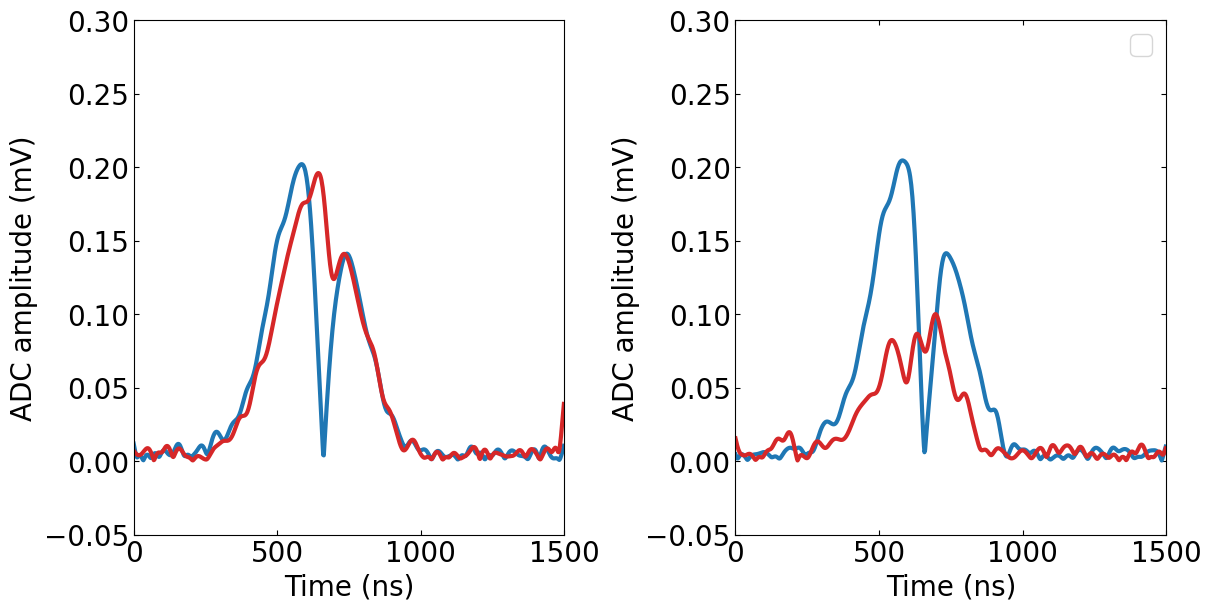

In [118]:
## waveform
ph_amp = 0
fogi_freq = 30

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
# ax[0].plot(d10[1][ph_amp][fogi_freq],  (d10[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[0].plot(d10[1][ph_amp][fogi_freq],  (d10[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[0].plot(d10[1][ph_amp][fogi_freq],  (d10[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[0].plot(d10[1][ph_amp][fogi_freq],  (d10[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.05, 0.3)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
# ax[1].plot(d11[1][ph_amp][fogi_freq],  (d11[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[1].plot(d11[1][ph_amp][fogi_freq],  (d11[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[1].plot(d11[1][ph_amp][fogi_freq],  (d11[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[1].plot(d11[1][ph_amp][fogi_freq],  (d11[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_ylim(-0.05, 0.3)
ax[1].set_xlim(0, 1500)
plt.legend()
print(np.round(d10[5][ph_amp][fogi_freq], 2))
print(np.round(d11[5][ph_amp][fogi_freq], 2))
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_14852\3301296466.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


11.94
3.84


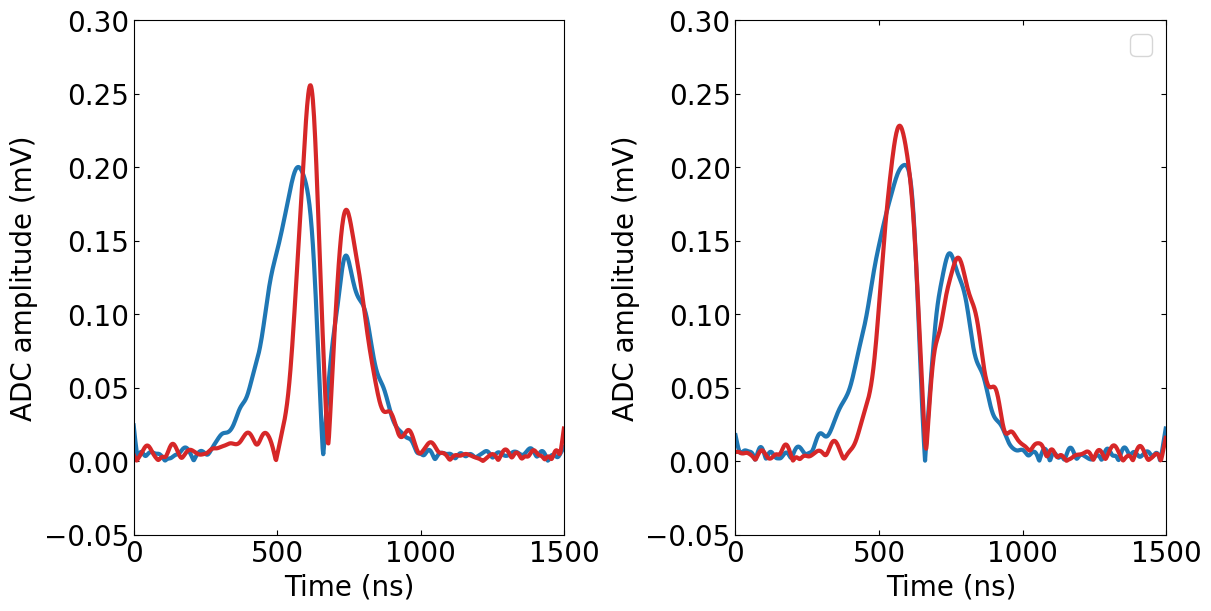

In [120]:
## waveform
ph_amp = 0
fogi_freq = 30

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
# ax[0].plot(d12[1][ph_amp][fogi_freq],  (d12[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[0].plot(d12[1][ph_amp][fogi_freq],  (d12[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[0].plot(d12[1][ph_amp][fogi_freq],  (d12[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[0].plot(d12[1][ph_amp][fogi_freq],  (d12[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.05, 0.3)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
# ax[1].plot(d13[1][ph_amp][fogi_freq],  (d13[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[1].plot(d13[1][ph_amp][fogi_freq],  (d13[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[1].plot(d13[1][ph_amp][fogi_freq],  (d13[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[1].plot(d13[1][ph_amp][fogi_freq],  (d13[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_ylim(-0.05, 0.3)
ax[1].set_xlim(0, 1500)
plt.legend()
print(np.round(d12[5][ph_amp][fogi_freq], 2))
print(np.round(d13[5][ph_amp][fogi_freq], 2))
plt.show()

phototn 2

In [26]:
ph2_fo0 = "/2024-11-15/2024-11-15T111758_d4ffed2f-j1_JPA_comm_timing"
ph2_fo1 = "/2024-11-15/2024-11-15T124126_7e29a207-j1_JPA_comm_timing"
ph2_fo2 = "/2024-11-15/2024-11-15T140446_2204720e-j1_JPA_comm_timing"
ph2_fo3 = "/2024-11-15/2024-11-15T152743_b8f9c36f-j1_JPA_comm_timing"

In [27]:
## absorption rate
ph_amp = 0
###############################################
data = ph2_fo0
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d20 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time20 = d20[0][ph_amp]
ph2fo0 = d20[5][ph_amp]

In [28]:
## absorption rate
ph_amp = 0
###############################################
data = ph2_fo1
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d21 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time21 = d21[0][ph_amp]
ph2fo1 = d21[5][ph_amp]

In [29]:
## absorption rate
ph_amp = 0
###############################################
data = ph2_fo2
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d22 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time22 = d22[0][ph_amp]
ph2fo2 = d22[5][ph_amp]

In [30]:
## absorption rate
ph_amp = 0
###############################################
data = ph2_fo3
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d23 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time23 = d23[0][ph_amp]
ph2fo3 = d23[5][ph_amp]

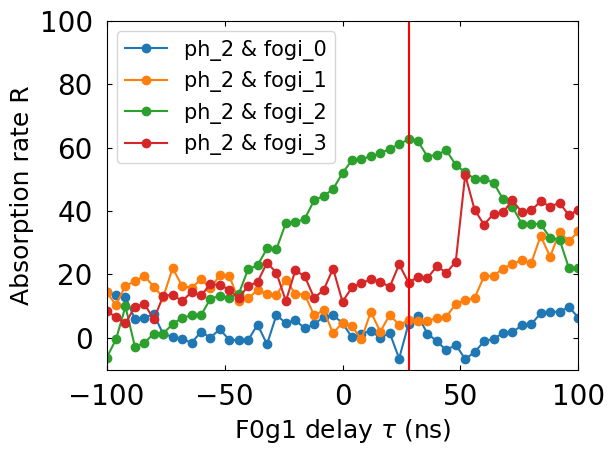

In [31]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time20, ph2fo0, "o-", label= "ph_2 & fogi_0")
plt.plot(time21, ph2fo1, "o-", label= "ph_2 & fogi_1")
plt.plot(time22, ph2fo2, "o-", label= "ph_2 & fogi_2")
plt.plot(time23, ph2fo3, "o-", label= "ph_2 & fogi_3")
plt.vlines(28, -10, 100, color="r")
plt.legend()
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_14852\3158485979.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


1.58
7.24


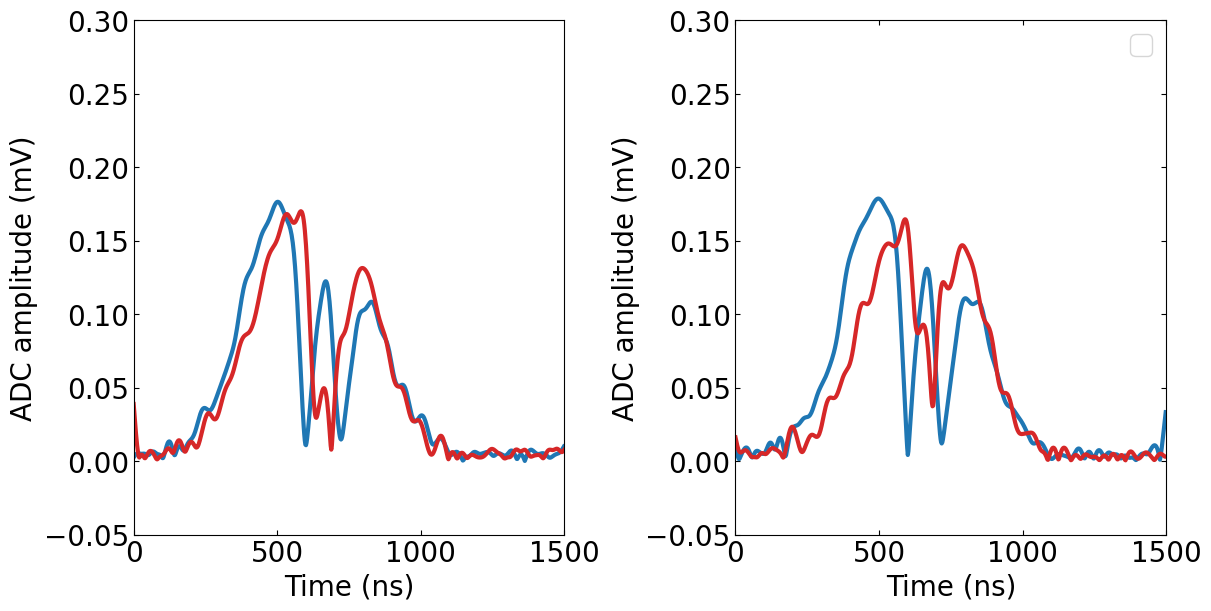

In [123]:
## waveform
ph_amp = 0
fogi_freq = 30

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
# ax[0].plot(d20[1][ph_amp][fogi_freq],  (d20[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[0].plot(d20[1][ph_amp][fogi_freq],  (d20[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[0].plot(d20[1][ph_amp][fogi_freq],  (d20[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[0].plot(d20[1][ph_amp][fogi_freq],  (d20[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.05, 0.3)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
# ax[1].plot(d21[1][ph_amp][fogi_freq],  (d21[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[1].plot(d21[1][ph_amp][fogi_freq],  (d21[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[1].plot(d21[1][ph_amp][fogi_freq],  (d21[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[1].plot(d21[1][ph_amp][fogi_freq],  (d21[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_ylim(-0.05, 0.3)
ax[1].set_xlim(0, 1500)
plt.legend()
print(np.round(d20[5][ph_amp][fogi_freq], 2))
print(np.round(d21[5][ph_amp][fogi_freq], 2))
plt.show()

59.68
16.04


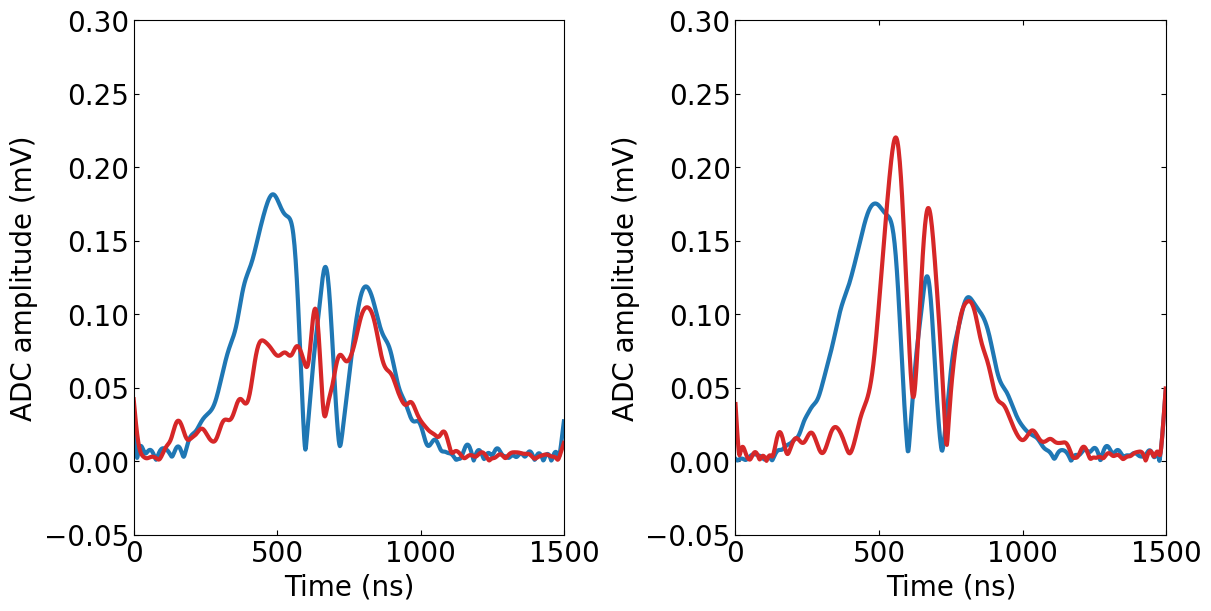

In [125]:
## waveform
ph_amp = 0
fogi_freq = 30

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
# ax[0].plot(d22[1][ph_amp][fogi_freq],  (d22[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue')# - np.mean(y_base))
ax[0].plot(d22[1][ph_amp][fogi_freq],  (d22[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue', label=r"reflection")
# ax[0].plot(d22[1][ph_amp][fogi_freq],  (d22[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8, color='tab:red')#-np.mean(y_absorbed))
ax[0].plot(d22[1][ph_amp][fogi_freq],  (d22[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red', label=r"absorption")
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.05, 0.3)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
# ax[1].plot(d23[1][ph_amp][fogi_freq],  (d23[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue')# - np.mean(y_base))
ax[1].plot(d23[1][ph_amp][fogi_freq],  (d23[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue', label=r"reflection")
# ax[1].plot(d23[1][ph_amp][fogi_freq],  (d23[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8, color='blue')#-np.mean(y_absorbed))
ax[1].plot(d23[1][ph_amp][fogi_freq],  (d23[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red', label=r"absorption")
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_ylim(-0.05, 0.3)
ax[1].set_xlim(0, 1500)
# plt.legend()
print(np.round(d22[5][ph_amp][fogi_freq], 2))
print(np.round(d23[5][ph_amp][fogi_freq], 2))
plt.show()

phototn 3

In [34]:
ph3_fo0 = "/2024-11-15/2024-11-15T164942_2c707bc5-j1_JPA_comm_timing"
ph3_fo1 = "/2024-11-15/2024-11-15T181022_7190bb31-j1_JPA_comm_timing"
ph3_fo2 = "/2024-11-15/2024-11-15T193127_c4ffe89d-j1_JPA_comm_timing"
ph3_fo3 = "/2024-11-15/2024-11-15T205353_4908ffd0-j1_JPA_comm_timing"

In [35]:
## absorption rate
ph_amp = 0
###############################################
data = ph3_fo0
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d30 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time30 = d30[0][ph_amp]
ph3fo0 = d30[5][ph_amp]

In [36]:
## absorption rate
ph_amp = 0
###############################################
data = ph3_fo1
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d31 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time31 = d31[0][ph_amp]
ph3fo1 = d31[5][ph_amp]

In [37]:
## absorption rate
ph_amp = 0
###############################################
data = ph3_fo2
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d32 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time32 = d32[0][ph_amp]
ph3fo2 = d32[5][ph_amp]

In [38]:
## absorption rate
ph_amp = 0
###############################################
data = ph3_fo3
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d33 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.47-9.35)*1e9)
time33 = d33[0][ph_amp]
ph3fo3 = d33[5][ph_amp]

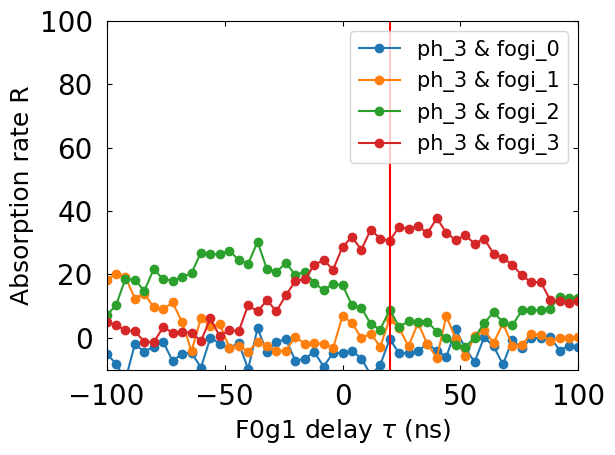

In [39]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time30, ph3fo0, "o-", label= "ph_3 & fogi_0")
plt.plot(time31, ph3fo1, "o-", label= "ph_3 & fogi_1")
plt.plot(time32, ph3fo2, "o-", label= "ph_3 & fogi_2")
plt.plot(time33, ph3fo3, "o-", label= "ph_3 & fogi_3")
plt.vlines(20, -10, 100, color="r")
plt.legend()
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_14852\1928935621.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


-0.37
6.02


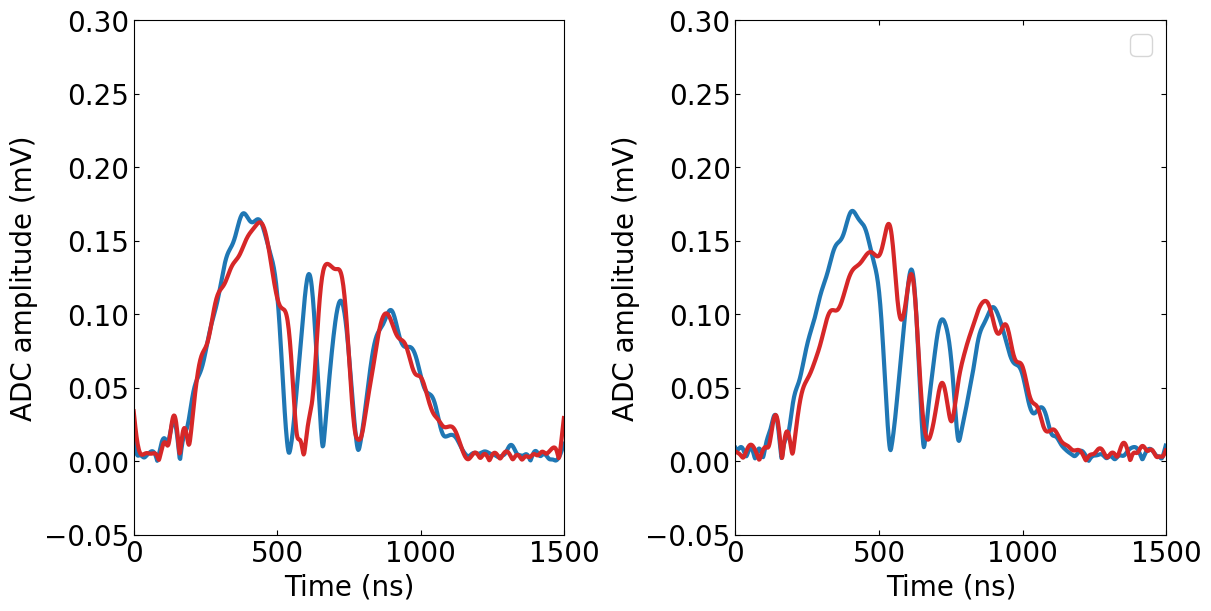

In [129]:
## waveform
ph_amp = 0
fogi_freq = 30

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
# ax[0].plot(d30[1][ph_amp][fogi_freq],  (d30[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[0].plot(d30[1][ph_amp][fogi_freq],  (d30[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[0].plot(d30[1][ph_amp][fogi_freq],  (d30[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[0].plot(d30[1][ph_amp][fogi_freq],  (d30[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.05, 0.3)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
# ax[1].plot(d31[1][ph_amp][fogi_freq],  (d31[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[1].plot(d31[1][ph_amp][fogi_freq],  (d31[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[1].plot(d31[1][ph_amp][fogi_freq],  (d31[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[1].plot(d31[1][ph_amp][fogi_freq],  (d31[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_ylim(-0.05, 0.3)
ax[1].set_xlim(0, 1500)
plt.legend()
print(np.round(d30[5][ph_amp][fogi_freq], 2))
print(np.round(d31[5][ph_amp][fogi_freq], 2))
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_14852\3530502125.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


8.91
30.68


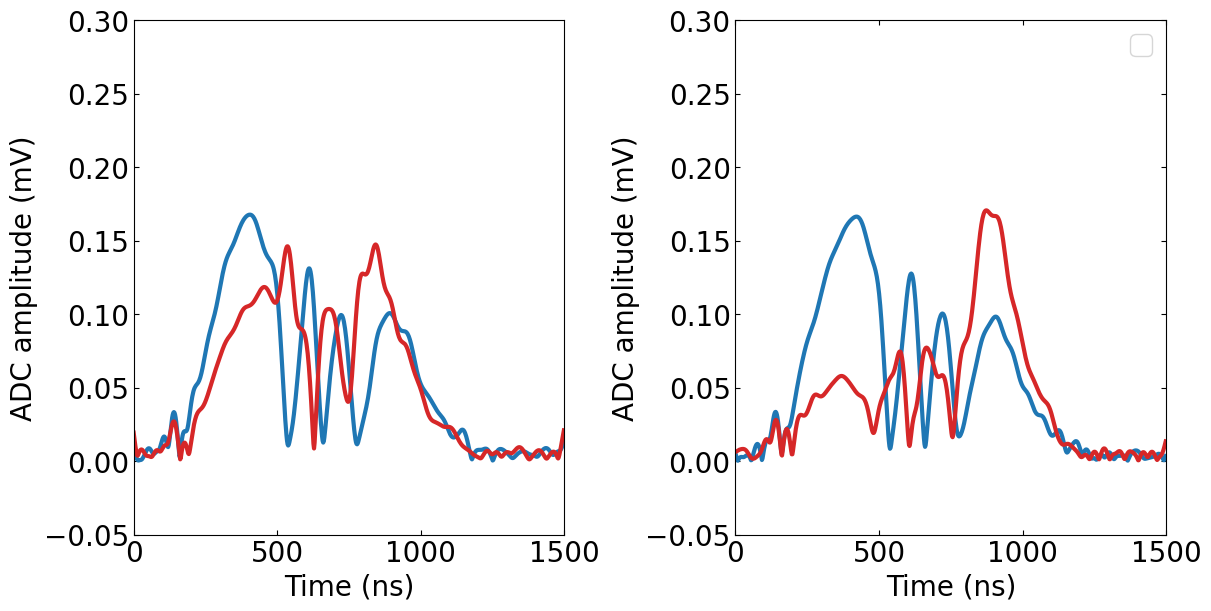

In [130]:
## waveform
ph_amp = 0
fogi_freq = 30

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
# ax[0].plot(d32[1][ph_amp][fogi_freq],  (d32[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[0].plot(d32[1][ph_amp][fogi_freq],  (d32[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[0].plot(d32[1][ph_amp][fogi_freq],  (d32[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[0].plot(d32[1][ph_amp][fogi_freq],  (d32[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.05, 0.3)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
# ax[1].plot(d33[1][ph_amp][fogi_freq],  (d33[3][ph_amp][fogi_freq])*1e3,lw=1, alpha=0.5, color='tab:blue', label=r"reflection")# - np.mean(y_base))
ax[1].plot(d33[1][ph_amp][fogi_freq],  (d33[8][ph_amp][fogi_freq])*1e3, lw=3, color='tab:blue')
# ax[1].plot(d33[1][ph_amp][fogi_freq],  (d33[2][ph_amp][fogi_freq])*1e3, lw=1, alpha=0.8,color='blue', label=r"absorption")#-np.mean(y_absorbed))
ax[1].plot(d33[1][ph_amp][fogi_freq],  (d33[7][ph_amp][fogi_freq])*1e3, lw=3, color='tab:red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_ylim(-0.05, 0.3)
ax[1].set_xlim(0, 1500)
plt.legend()
print(np.round(d32[5][ph_amp][fogi_freq], 2))
print(np.round(d33[5][ph_amp][fogi_freq], 2))
plt.show()

## analysis

In [252]:
i = 30
data = np.array([[ph3fo0[i], ph3fo1[i], ph3fo2[i], ph3fo3[i]],
                [ph2fo0[i], ph2fo1[i], ph2fo2[i], ph2fo3[i]],
                [ph1fo0[i], ph1fo1[i], ph1fo2[i], ph1fo3[i]],
                [ph0fo0[i], ph0fo1[i], ph0fo2[i], ph0fo3[i]]])

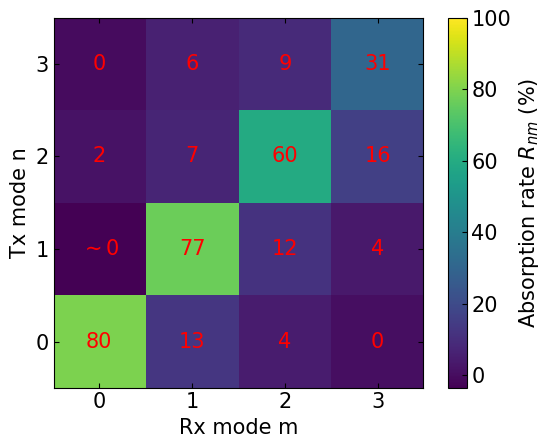

In [253]:
extent = (0, 3, 0, 3)

plt.imshow(data, extent=extent, filternorm=False, vmax=100)
colorbar = plt.colorbar(label="Absorption rate $R_{nm}$ (%)")
colorbar.set_ticks([0, 20, 40, 60, 80, 100])
plt.ylabel("Tx mode n")
plt.xlabel("Rx mode m")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
num_x_ticks = data.shape[1]
num_y_ticks = data.shape[0]
x_ticks = np.linspace(extent[0] + 0.37, extent[1] - 0.37, num_x_ticks)
y_ticks = np.linspace(extent[2] + 0.37, extent[3] - 0.37, num_y_ticks)
plt.xticks(x_ticks, range(num_x_ticks))
plt.yticks(y_ticks, range(num_y_ticks))

for i in range(num_y_ticks):
    for j in range(num_x_ticks):
        if int(np.round(data[j, i])) < 0:
            value = r"$\sim 0$"
        else:
            value = int(np.round(data[j, i]))
        plt.text(x_ticks[i], 3-y_ticks[j], f"{value}", ha='center', va='center', color="red")

plt.savefig('abs_data.png', bbox_inches='tight')
plt.show()

In [45]:
def sech_0(time, const):
    return (const/2)**0.5/np.cosh(const*time)

def sech_1(time, const):
    return (6*const**3/(np.pi**2))**0.5/np.cosh(const*time)*time

def sech_2(time, const):
    return (45*(2*const)**5/64/(np.pi**4))**0.5/np.cosh(const*time)*(time**2-(np.pi/2/const)**2/3)

def sech_3(time, const):
    return (175*(2*const)**7)**0.5/24/(np.pi**3)/np.cosh(const*time)*(time**3-(7*time*(np.pi/(2*const))**2/5))

In [46]:
const = 2.5e-3 * 2 * np.pi

def sech_00(time, tau):
    return sech_0(time, const)*sech_0(time+tau, const)
def sech_01(time, tau):
    return sech_0(time, const)*sech_1(time+tau, const)
def sech_11(time, tau):
    return sech_1(time, const)*sech_1(time+tau, const)

def sech_02(time, tau):
    return sech_0(time, const)*sech_2(time+tau, const)
def sech_12(time, tau):
    return sech_1(time, const)*sech_2(time+tau, const)
def sech_22(time, tau):
    return sech_2(time, const)*sech_2(time+tau, const)

def sech_03(time, tau):
    return sech_0(time, const)*sech_3(time+tau, const)
def sech_13(time, tau):
    return sech_1(time, const)*sech_3(time+tau, const)
def sech_23(time, tau):
    return sech_2(time, const)*sech_3(time+tau, const)
def sech_33(time, tau):
    return sech_3(time, const)*sech_3(time+tau, const)

In [47]:

def sech_02(time, tau):
    return sech_0(time, const)*sech_2(time+tau, const)
def sech_12(time, tau):
    return sech_1(time, const)*sech_2(time+tau, const)
def sech_22(time, tau):
    return sech_2(time, const)*sech_2(time+tau, const)

def sech_03(time, tau):
    return sech_0(time, const)*sech_3(time+tau, const)
def sech_13(time, tau):
    return sech_1(time, const)*sech_3(time+tau, const)
def sech_23(time, tau):
    return sech_2(time, const)*sech_3(time+tau, const)
def sech_33(time, tau):
    return sech_3(time, const)*sech_3(time+tau, const)

In [48]:
def fit_waveform(time, data, x0=[2e-3,400], get_center=False, curve='sech', **kwargs):
    if curve=='sech':
        func = lambda x: x[0]/np.cosh(kwargs['kappa']*(time-x[1]))
        cost_func = lambda x: np.linalg.norm(x[0]/np.cosh(kwargs['kappa']*(time-x[1])) - data)
    elif curve=="sech_1":
        func = lambda x: np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_2":
        func = lambda x: np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_3":
        func = lambda x: np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    
    best_x = optimize.minimize(cost_func, x0=x0,method='Nelder-Mead',)
    # print(best_x)
    # print(f"center:{best_x.x}")
    if get_center==True:
        return best_x.x, func(best_x.x)
    return func(best_x.x)

In [49]:
result_dict_tx = dict(
    data_ph0 = dict(target_freq=9.35, date="2024-11-13", acquire_time="221055"),
    data_ph1 = dict(target_freq=9.35, date="2024-11-13", acquire_time="221150"),
    data_ph2 = dict(target_freq=9.35, date="2024-11-13", acquire_time="221242"),
    data_ph3 = dict(target_freq=9.35, date="2024-11-13", acquire_time="221334"),
)

In [50]:
result_dict_rx = dict(
    data_ph0 = dict(target_freq=9.35, date="2024-11-13", acquire_time="223350"),
    data_ph1 = dict(target_freq=9.35, date="2024-11-13", acquire_time="223445"),
    data_ph2 = dict(target_freq=9.35, date="2024-11-13", acquire_time="223537"),
    data_ph3 = dict(target_freq=9.35, date="2024-11-13", acquire_time="223630"),
)

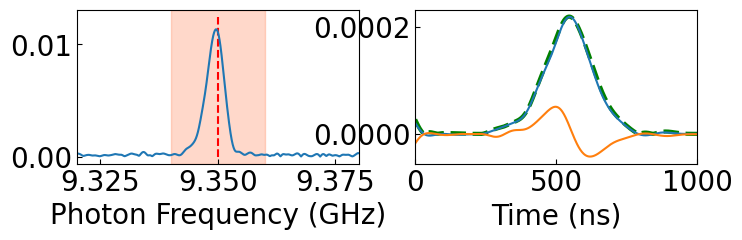

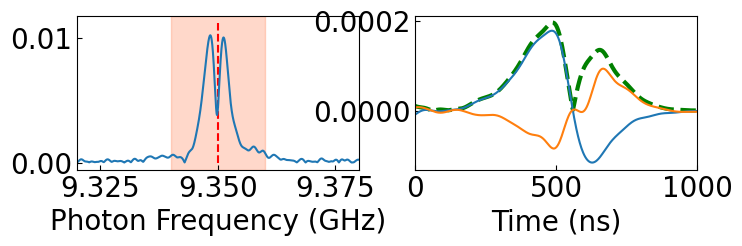

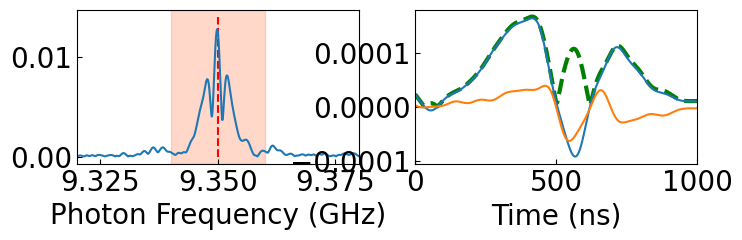

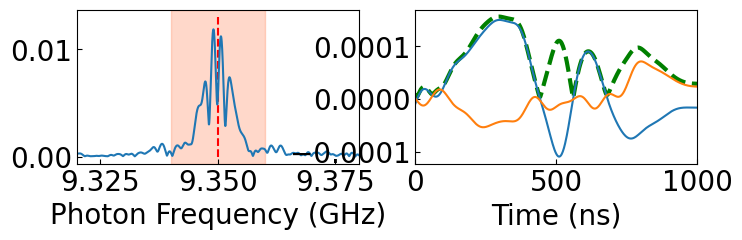

In [51]:
from datataking import search_datadict_miyamura
readout_lo_freq = 9.47
passing_band = 0.01
duration=1000
cd = "CDY170"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

signals_tx = []
for k, v in result_dict_tx.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    norm=np.sum(2*np.abs(signal)**2)**0.5
    signals_tx.append(signal/norm)
    # res = fit_waveform(time, np.abs(signal), curve="sech_3", kappa=const)
    # ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)

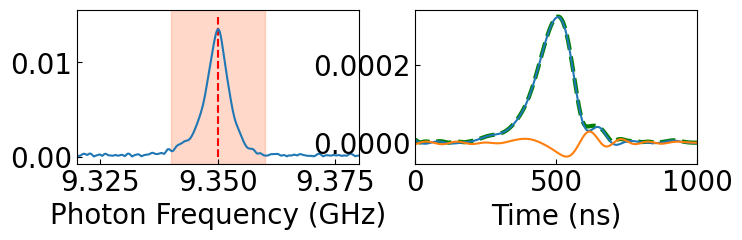

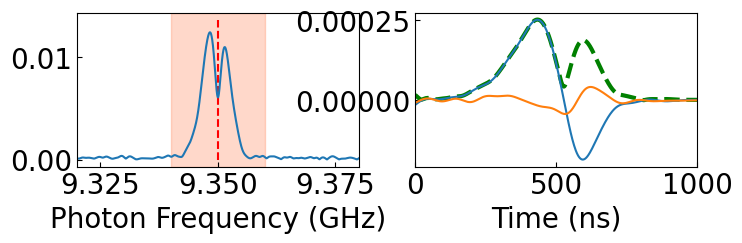

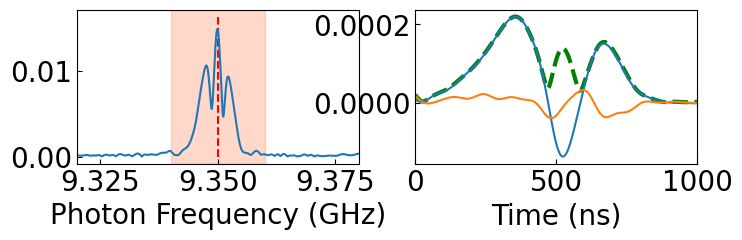

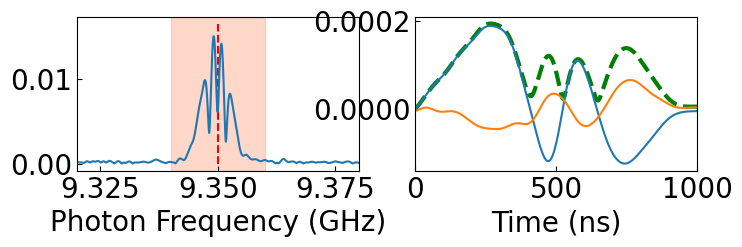

In [52]:
from datataking import search_datadict_miyamura
readout_lo_freq = 9.47
passing_band = 0.01
duration=1000
cd = "CDY170"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

signals_rx = []
for k, v in result_dict_rx.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    norm=np.sum(2*np.abs(signal)**2)**0.5
    signals_rx.append(signal/norm)
    # res = fit_waveform(time, np.abs(signal), curve="sech_3", kappa=const)
    # ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)

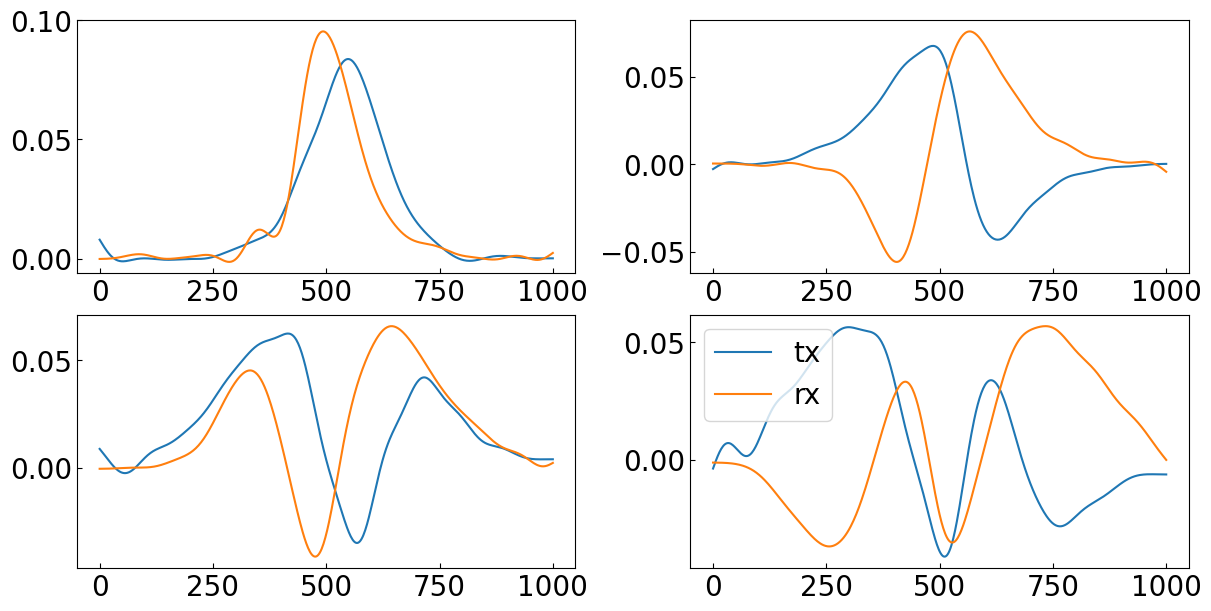

In [53]:
signal_ph0_tx, signal_ph1_tx, signal_ph2_tx, signal_ph3_tx = signals_tx[0], signals_tx[1], signals_tx[2], signals_tx[3]
signal_ph0_rx, signal_ph1_rx, signal_ph2_rx, signal_ph3_rx = signals_rx[0][::-1], signals_rx[1][::-1], signals_rx[2][::-1], signals_rx[3][::-1]
data_t = np.linspace(0, 1000, 501)
def signal_cohe0(tau):
     return sech_0(data_t+tau-500, const)
def signal_cohe1(tau):
     return sech_1(data_t+tau-500, const)
def signal_cohe2(tau):
     return sech_2(data_t+tau-500, const)
def signal_cohe3(tau):
     return sech_3(data_t+tau-500, const)

fig, ax = plt.subplots(2,2,figsize=(12,6),constrained_layout=True)
tau = 0
ax[0][0].plot(data_t, signal_ph0_tx.real, label ='tx')
ax[0][0].plot(data_t, signal_ph0_rx.real, label ='rx')

ax[0][1].plot(data_t, signal_ph1_tx.real, label ='tx')
ax[0][1].plot(data_t, signal_ph1_rx.real, label ='rx')

ax[1][0].plot(data_t, signal_ph2_tx.real, label ='tx')
ax[1][0].plot(data_t, signal_ph2_rx.real, label ='rx')

ax[1][1].plot(data_t, signal_ph3_tx.real, label ='tx')
ax[1][1].plot(data_t, signal_ph3_rx.real, label ='rx')
plt.legend()

In [54]:
from scipy.integrate import quad

def overlap(func, taus, time):
    ys = []
    for t in taus:
        def new_func(t_value):
            return func(time=t_value, tau=t)
        integral_value = abs(quad(new_func, time[0], time[-1])[0])**2
        ys.append(integral_value)
    return np.array(ys) * 100

In [55]:
def overlap_exp(data_func, ideal_func, taus, time):
    ys = []
    for t in taus:
        new_func = data_func * ideal_func(tau=t)
        y = np.abs((np.sum(new_func) * 2))**2
        ys.append(y)
    return np.array(ys)*100

In [210]:
from scipy.ndimage import shift as nd_shift
def roll_with_interpolation(array, shift):
    """
    浮動小数点のシフトをサポート。
    左右に外れた部分には0を埋める。
    """
    return nd_shift(array, shift=shift, mode='constant', cval=0.0)

In [56]:
def roll_with_zeros(array, shift):
    if shift > 0:
        rolled = np.roll(array, shift)
        rolled[:shift] = 0 
    elif shift < 0:
        rolled = np.roll(array, shift)
        rolled[shift:] = 0 
    else:
        rolled = array
    return rolled

In [215]:
def overlap_comm(data_tx, data_rx, taus):
    ys = []
    for tau in taus:
        shift = tau/2
        # shifted_data_rx = roll_with_zeros(data_rx, shift=shift)
        shifted_data_rx = roll_with_interpolation(data_rx, shift=shift)
        new_func = data_tx * shifted_data_rx
        y = np.abs(np.sum(new_func) * 2)**2
        ys.append(y)
    return np.array(ys) * 100

In [216]:
taus = np.linspace(-100, 100, 51, dtype=int)
from matplotlib.lines import Line2D

In [241]:
def overlap_curve_fitting(data, signal_ph_tx, signal_ph_rx):
    def overlap_curve(taus, delay):
        def new_func(taus, delay):
            delay = int(round(delay))
            return overlap_comm(signal_ph_tx, signal_ph_rx, taus + delay)
        return new_func(taus, delay)

    par_ini = {'delay':52}
    par_min = {'delay': -np.inf}
    par_max = {'delay': np.inf}
    par_vary = {'delay': True}

    model = lmfit.Model(overlap_curve)

    params = model.make_params()
    for name in model.param_names:
        params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    result = model.fit(data = data, params = params, taus = taus, method='nelder-mead')
    print(result.params['delay'].value)
    return result

55.900000000000006
44.199999999999996
48.099999999999994
50.7


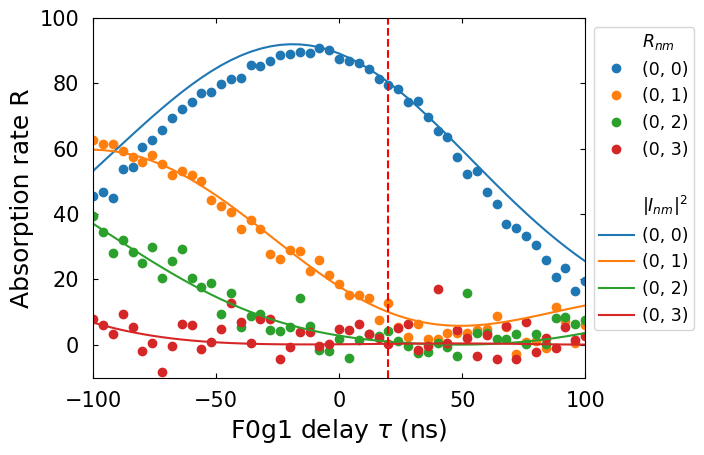

In [237]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time00, ph0fo0, "o", label= "ph_0 & fogi_0")
plt.plot(time01, ph0fo1, "o", label= "ph_0 & fogi_1")
plt.plot(time02, ph0fo2, "o", label= "ph_0 & fogi_2")
plt.plot(time03, ph0fo3, "o", label= "ph_0 & fogi_3")
plt.plot(taus, overlap_curve_fitting(ph0fo0, signal_ph0_tx, signal_ph0_rx).best_fit, color="tab:blue")
plt.plot(taus, overlap_curve_fitting(ph0fo1, signal_ph0_tx, signal_ph1_rx).best_fit, color="tab:orange")
plt.plot(taus, overlap_curve_fitting(ph0fo2, signal_ph0_tx, signal_ph2_rx).best_fit, color="tab:green")
plt.plot(taus, overlap_curve_fitting(ph0fo3, signal_ph0_tx, signal_ph3_rx).best_fit, color="tab:red")
plt.vlines(20, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),  # データタイトル
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(0, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(0, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(0, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(0, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),  # 空白行を挿入
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"),  # フィットタイトル
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(0, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(0, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(0, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(0, 3)"),
]

# 凡例の表示
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5,
           borderpad=0.3 )
plt.show()

66.30000000000004
53.3
48.099999999999994
50.05


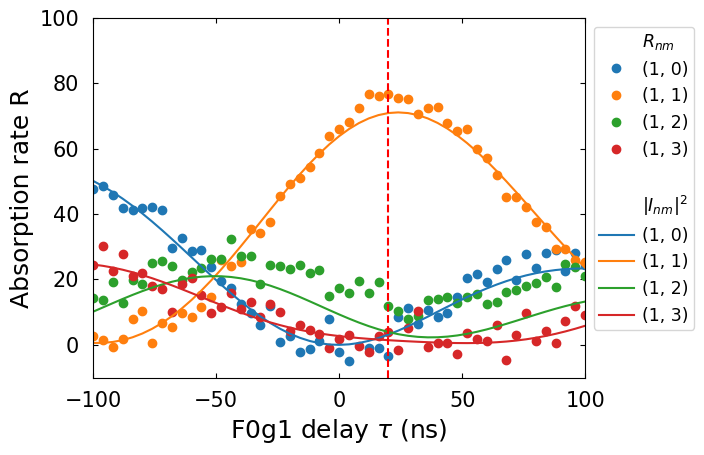

In [247]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time10, ph1fo0, "o", label= "ph_1 & fogi_0")
plt.plot(time11, ph1fo1, "o", label= "ph_1 & fogi_1")
plt.plot(time12, ph1fo2, "o", label= "ph_1 & fogi_2")
plt.plot(time13, ph1fo3, "o", label= "ph_1 & fogi_3")
plt.plot(taus, overlap_curve_fitting(ph1fo0, signal_ph1_tx, signal_ph0_rx).best_fit, color="tab:blue")
plt.plot(taus, overlap_curve_fitting(ph1fo1, signal_ph1_tx, signal_ph1_rx).best_fit, color="tab:orange")
plt.plot(taus, overlap_curve_fitting(ph1fo2, signal_ph1_tx, signal_ph2_rx).best_fit, color="tab:green")
plt.plot(taus, overlap_curve_fitting(ph1fo3, signal_ph1_tx, signal_ph3_rx).best_fit, color="tab:red")
plt.vlines(20, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),  # データタイトル
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(1, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(1, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(1, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(1, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),  # 空白行を挿入
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"),  # フィットタイトル
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(1, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(1, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(1, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(1, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5,
           borderpad=0.3 )
plt.show()

67.60000000000002
66.95000000000005
52.0
92.30000000000005


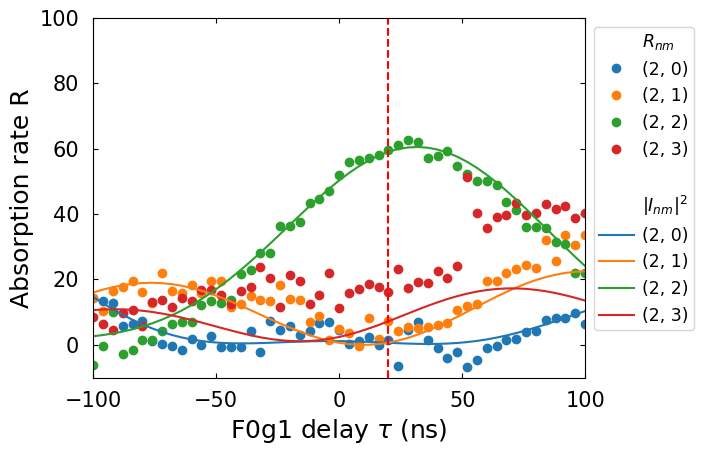

In [251]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time20, ph2fo0, "o", label= "ph_2 & fogi_0")
plt.plot(time21, ph2fo1, "o", label= "ph_2 & fogi_1")
plt.plot(time22, ph2fo2, "o", label= "ph_2 & fogi_2")
plt.plot(time23, ph2fo3, "o", label= "ph_2 & fogi_3")
plt.plot(taus, overlap_curve_fitting(ph2fo0, signal_ph2_tx, signal_ph0_rx).best_fit, color="tab:blue")
plt.plot(taus, overlap_curve_fitting(ph2fo1, signal_ph2_tx, signal_ph1_rx).best_fit, color="tab:orange")
plt.plot(taus, overlap_curve_fitting(ph2fo2, signal_ph2_tx, signal_ph2_rx).best_fit, color="tab:green")
plt.plot(taus, overlap_curve_fitting(ph2fo3, signal_ph2_tx, signal_ph3_rx).best_fit, color="tab:red")
plt.vlines(20, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),  # データタイトル
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(2, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(2, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(2, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(2, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),  # 空白行を挿入
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"),  # フィットタイトル
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(2, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(2, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(2, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(2, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5,
           borderpad=0.3 )
# plt.legend()
plt.show()

52.0
62.40000000000002
40.949999999999996
42.89999999999999


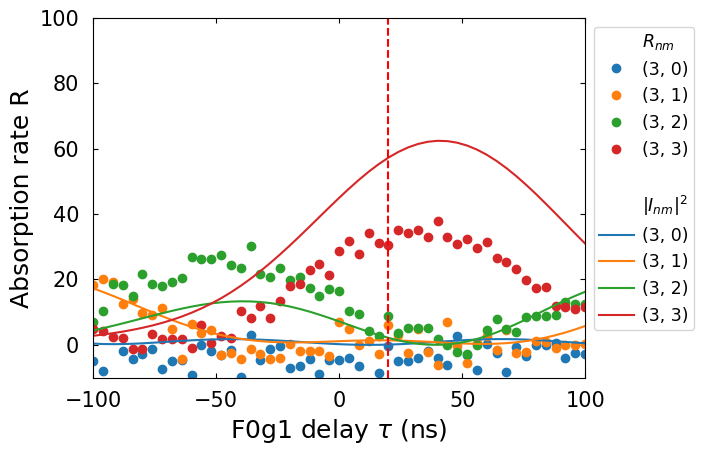

In [249]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time30, ph3fo0, "o", label= "ph_3 & fogi_0")
plt.plot(time31, ph3fo1, "o", label= "ph_3 & fogi_1")
plt.plot(time32, ph3fo2, "o", label= "ph_3 & fogi_2")
plt.plot(time33, ph3fo3, "o", label= "ph_3 & fogi_3")
plt.plot(taus, overlap_curve_fitting(ph3fo0, signal_ph3_tx, signal_ph0_rx).best_fit, color="tab:blue")
plt.plot(taus, overlap_curve_fitting(ph3fo1, signal_ph3_tx, signal_ph1_rx).best_fit, color="tab:orange")
plt.plot(taus, overlap_curve_fitting(ph3fo2, signal_ph3_tx, signal_ph2_rx).best_fit, color="tab:green")
plt.plot(taus, overlap_curve_fitting(ph3fo3, signal_ph3_tx, signal_ph3_rx).best_fit, color="tab:red")
plt.vlines(20, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),  # データタイトル
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(3, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(3, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(3, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(3, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),  # 空白行を挿入
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"),  # フィットタイトル
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(3, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(3, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(3, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(3, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5,
           borderpad=0.3 )
plt.show()